# SMD random window synthetic anomaly viewer

Notebook này lấy ngẫu nhiên 1 window sạch từ 3 entity SMD `machine-1-6`, `machine-3-4`, `machine-3-9`, rồi inject đúng 11 synthetic anomaly classes của codebase.

Mỗi lần bấm `Run All` sẽ random lại window gốc. 12 panel liên tiếp gồm `normal` + 11 class:
`spike`, `flip`, `speedup`, `noise`, `cutoff`, `average`, `scale`, `wander`, `contextual`, `upsidedown`, `mixture`.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import sys

sys.path.append("../")

from src.data.augment import (
    REDLAMP_ANOMALY_FAMILIES,
    REDLAMP_MULTICLASS_CLASS_NAMES,
    SyntheticAnomalyInjector,
)
from src.data.collate import collate_windows
from src.data.loaders import build_smd_dataset_bundle

current_dir = Path.cwd().resolve()
project_root = current_dir if (current_dir / "data").exists() else current_dir.parent

data_root = project_root / "data" / "ServerMachineDataset"
entity_ids = ["machine-1-6", "machine-3-4", "machine-3-9"]
window_size = 20
stride = 1

print("Project root:", project_root)
print("Data root:", data_root)
print("Synthetic anomaly class names:", REDLAMP_MULTICLASS_CLASS_NAMES)
print("Anomaly families only:", REDLAMP_ANOMALY_FAMILIES)

Project root: /Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026
Data root: /Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset
Synthetic anomaly class names: ('normal', 'spike', 'flip', 'speedup', 'noise', 'cutoff', 'average', 'scale', 'wander', 'contextual', 'upsidedown', 'mixture')
Anomaly families only: ('spike', 'flip', 'speedup', 'noise', 'cutoff', 'average', 'scale', 'wander', 'contextual', 'upsidedown', 'mixture')


In [6]:
data_bundle = build_smd_dataset_bundle(
    {
        "dataset_name": "smd",
        "root_dir": str(data_root),
        "entity_ids": entity_ids,
        "validation_split_ratio": 0.2,
        "window_size": window_size,
        "stride": stride,
        "batch_size": 1,
        "num_workers": 0,
        "shuffle_train": False,
    }
)

train_dataset = data_bundle["datasets"]["train"]
window_indices_by_entity: dict[str, list[int]] = {
    entity_id: [] for entity_id in entity_ids
}

for window_index, (sequence_index, _, _) in enumerate(train_dataset.index_records):
    entity_id = train_dataset.sequences[sequence_index]["meta"]["entity_id"]
    if entity_id in window_indices_by_entity:
        window_indices_by_entity[entity_id].append(window_index)

rng = np.random.default_rng()
selected_entity_id = str(rng.choice(entity_ids))
selected_window_index = int(rng.choice(window_indices_by_entity[selected_entity_id]))
clean_window_item = train_dataset[selected_window_index]
clean_batch = collate_windows([clean_window_item])

print("Selected entity:", selected_entity_id)
print("Selected window index:", selected_window_index)
print("Window shape:", tuple(clean_batch["x"].shape))

[DATA] Resolved SMD dataset root | input_root=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset, configured_root_dir=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset, resolved_root=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset, used_environment_override=False
[DATA] Resolved SMD root directory for loader builder | resolved_root_dir=/Users/conquerormikrokosmos/Downloads/LAPTOP MAC/MYUNIVERSITY/ĐẠI HỌC QUỐC GIA TPHCM/ĐH KHOA HỌC TỰ NHIÊN/Khoá luận tốt nghiệp/bachelor-thesis-2026/data/ServerMachineDataset
[DATA] Building SMD dataset bundle | resolved_root_dir=

In [7]:
def build_augmented_batch(
    clean_batch: dict, anomaly_family: str, seed_offset: int
) -> dict:
    injector = SyntheticAnomalyInjector(
        anomaly_probability=1.0,
        min_segment_fraction=0.2,
        max_segment_fraction=0.3,
        anomaly_families=(anomaly_family,),
        train_balance_classes=False,
        classification_label_mode="redlamp_multiclass",
        deterministic_seed=seed_offset,
    )
    return injector.augment_batch(clean_batch)


def select_plot_channels(affected_channels: list[int], num_channels: int) -> list[int]:
    selected_channels = sorted(
        {int(channel_index) for channel_index in affected_channels}
    )
    if selected_channels:
        return selected_channels[:3]
    return list(range(min(3, num_channels)))


plot_entries = []
for family_index, anomaly_family in enumerate(REDLAMP_ANOMALY_FAMILIES, start=1):
    augmented_batch = build_augmented_batch(clean_batch, anomaly_family, family_index)
    anomaly_metadata = augmented_batch["augmentation_metadata"][0]
    plot_channels = select_plot_channels(
        affected_channels=list(anomaly_metadata.get("affected_channels", [])),
        num_channels=int(clean_batch["x"].shape[-1]),
    )
    plot_entries.append(
        (
            "reference",
            anomaly_family,
            clean_batch,
            clean_batch["meta"][0],
            plot_channels,
        )
    )
    plot_entries.append(
        (
            "anomaly",
            anomaly_family,
            augmented_batch,
            anomaly_metadata,
            plot_channels,
        )
    )

print(
    "Panels:",
    [panel_kind + ":" + class_name for panel_kind, class_name, _, _, _ in plot_entries],
)

[DATA] Augmented multitask batch | input_x=shape=(1, 20, 38), dtype=torch.float32, device=cpu, output_x=shape=(1, 20, 38), dtype=torch.float32, device=cpu, anomaly_mask=shape=(1, 20), dtype=torch.int64, device=cpu, anomalous_windows=1, classification_label_distribution={1=1}, anomaly_families_present=[spike]
[DATA] Augmented multitask batch | input_x=shape=(1, 20, 38), dtype=torch.float32, device=cpu, output_x=shape=(1, 20, 38), dtype=torch.float32, device=cpu, anomaly_mask=shape=(1, 20), dtype=torch.int64, device=cpu, anomalous_windows=1, classification_label_distribution={2=1}, anomaly_families_present=[flip]
[DATA] Augmented multitask batch | input_x=shape=(1, 20, 38), dtype=torch.float32, device=cpu, output_x=shape=(1, 20, 38), dtype=torch.float32, device=cpu, anomaly_mask=shape=(1, 20), dtype=torch.int64, device=cpu, anomalous_windows=1, classification_label_distribution={3=1}, anomaly_families_present=[speedup]
[DATA] Augmented multitask batch | input_x=shape=(1, 20, 38), dtype=t

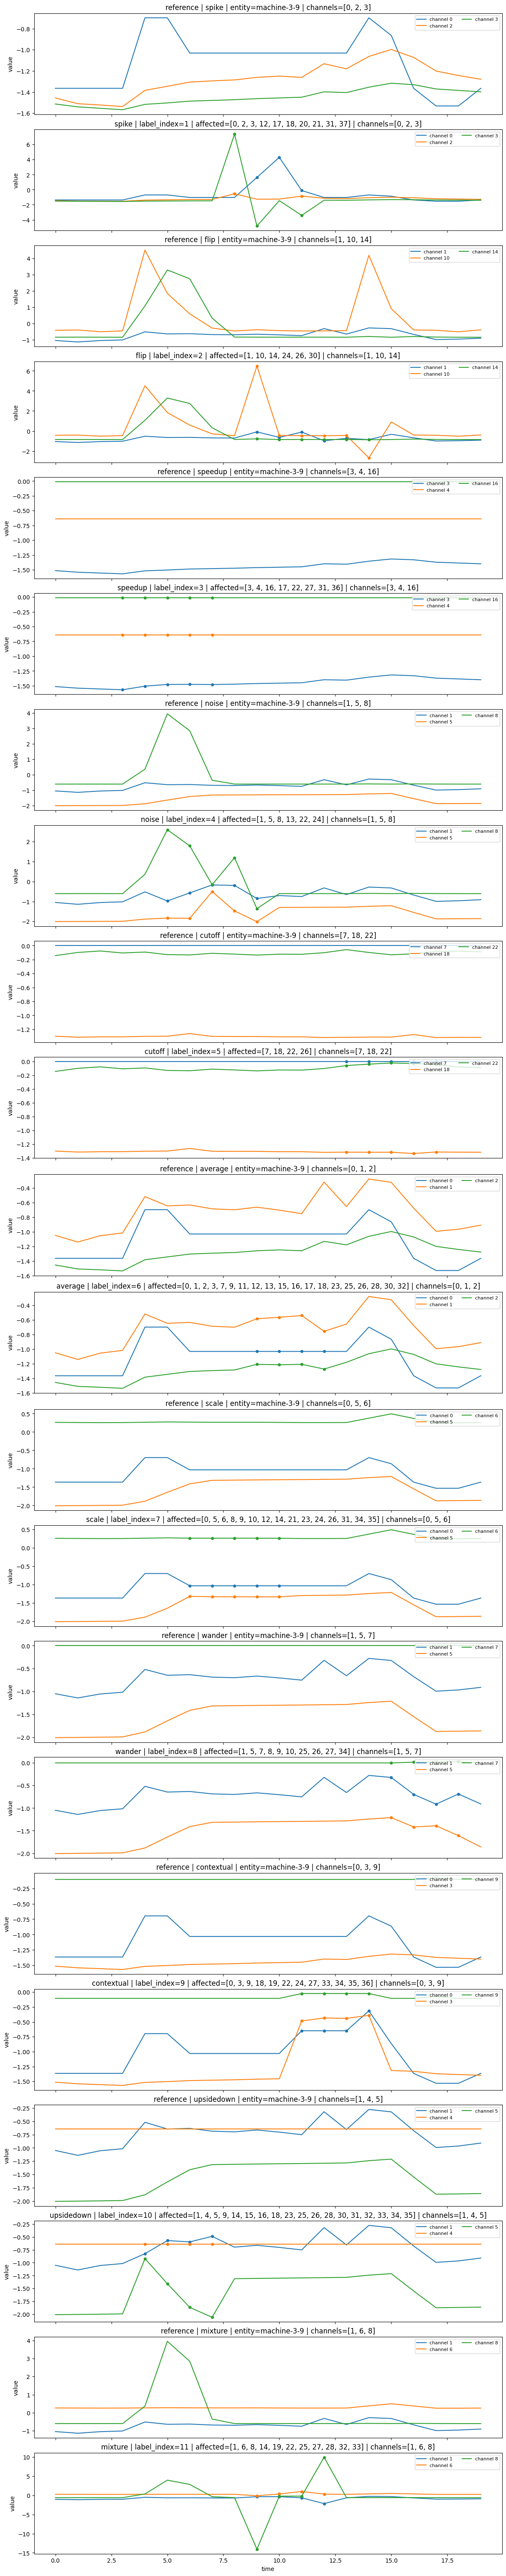

In [8]:
plot_windows = [
    batch["x"][0].detach().cpu().numpy() for _, _, batch, _, _ in plot_entries
]

figure, axes = plt.subplots(
    len(plot_entries),
    1,
    figsize=(12, 2.8 * len(plot_entries)),
    constrained_layout=True,
    sharex=True,
)

if len(plot_entries) == 1:
    axes = [axes]

for axis, (panel_kind, class_name, batch, metadata, plot_channels), window_array in zip(
    axes, plot_entries, plot_windows
):
    for channel_index in plot_channels:
        (line,) = axis.plot(
            window_array[:, channel_index],
            label=f"channel {channel_index}",
            linewidth=1.5,
        )
        if panel_kind == "anomaly":
            family_parameters_by_channel = metadata.get(
                "family_parameters_by_channel", {}
            )
            channel_parameters = family_parameters_by_channel.get(
                str(channel_index), {}
            )
            changed_positions = channel_parameters.get("changed_positions", [])
            if changed_positions:
                axis.scatter(
                    changed_positions,
                    [
                        window_array[position, channel_index]
                        for position in changed_positions
                    ],
                    color=line.get_color(),
                    s=18,
                    zorder=3,
                )
    if panel_kind == "reference":
        axis.set_title(
            f"reference | {class_name} | entity={metadata['entity_id']} | channels={plot_channels}"
        )
    else:
        axis.set_title(
            f"{class_name} | label_index={int(batch['classification_labels'][0])} | affected={metadata['affected_channels']} | channels={plot_channels}"
        )
    axis.set_ylabel("value")
    axis.legend(loc="upper right", fontsize=8, ncol=2)

axes[-1].set_xlabel("time")
plt.show()